# Online CAPTCHA inference with QEM

This notebook runs QEM on an image from `data/examples`. It uses the full
texture and whole-image diffeomorphic-warp model, but restricts the
230,400-dimensional count lattice to observation-specific candidate sites.

For each latent factor, QEM estimates its sufficient-statistic mean using
self-normalized marginal importance weights:

$$
\widehat m_i=\sum_k\widetilde w_{ik}T_i(z_{ik}),\qquad
m_{i,t}=\lambda_t m_{i,t-1}+(1-\lambda_t)\widehat m_i.
$$

The final cells show the reconstruction, inferred candidate occupancies,
and the relative QEM marginal-objective trace.


In [1]:
from pathlib import Path

import hydra
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import rootutils
from PIL import Image

PROJECT_ROOT = rootutils.setup_root(
    Path.cwd(), indicator=".project-root", pythonpath=True
)

from src.inference.qem_online import QEMCaptchaInference


In [2]:
EXAMPLE_INDEX = 0
NUM_CANDIDATES = 6
NUM_POSTERIOR_SAMPLES = 16
NUM_SAMPLES = 4
NUM_STEPS = 10
SEED = 0


def load_image(path, shape=(80, 80)):
    height, width = shape
    image = Image.open(path).convert("RGB").resize((width, height))
    array = np.asarray(image, dtype=np.float32) / 255.0
    return jnp.asarray(array)[None]


def plot_candidate_sites(axis, image, sites, strengths=None):
    axis.imshow(np.asarray(image))
    strengths = (
        np.ones(len(sites)) if strengths is None else np.asarray(strengths)
    )
    sizes = 30.0 + 90.0 * strengths / max(float(strengths.max()), 1e-6)
    axis.scatter(
        np.asarray(sites[:, 1]),
        np.asarray(sites[:, 0]),
        facecolors="none",
        edgecolors="tab:red",
        s=sizes,
    )
    axis.set_axis_off()


## Inspect the available observations

Change `EXAMPLE_INDEX` above to fit a different image. The gallery is kept
separate from inference so trying another example requires rerunning only
the cells below it.


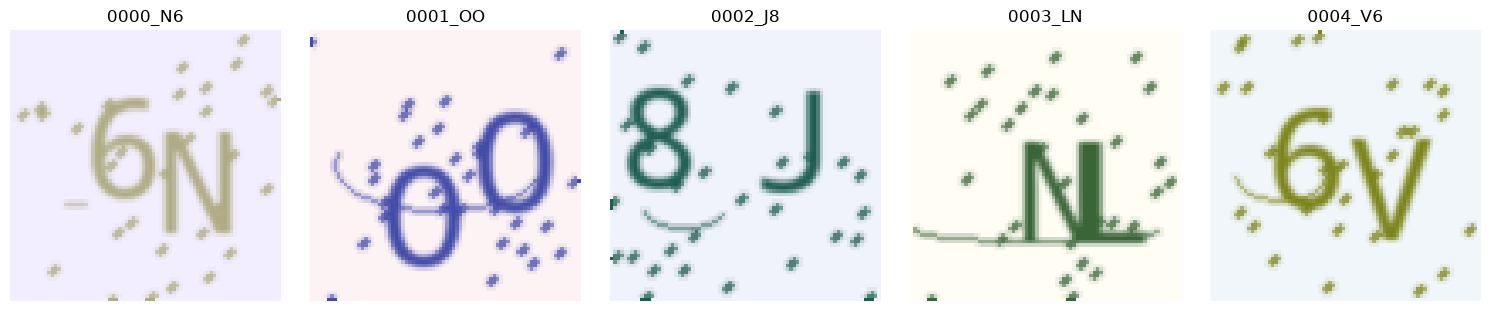

In [3]:
example_paths = sorted((PROJECT_ROOT / "data/examples").glob("*.png"))
if not example_paths:
    raise FileNotFoundError(PROJECT_ROOT / "data/examples")

figure, axes = plt.subplots(
    1, len(example_paths), figsize=(3 * len(example_paths), 3),
    constrained_layout=True, squeeze=False,
)
for axis, path in zip(axes[0], example_paths):
    axis.imshow(np.asarray(load_image(path)[0]))
    axis.set_title(path.stem)
    axis.set_axis_off()
selected_path = example_paths[EXAMPLE_INDEX]


## Fit the candidate-restricted posterior

`NUM_SAMPLES=4` forms $4^4=256$ combinations across counts, color, texture,
and velocity at each update. Ten updates make this notebook reasonably
quick to execute. Increase both sample and step counts for an actual
recovery run; the cell reports the settings alongside its output. The
initial proposal reserves 20% of its count mass for class alternatives and
puts the remainder on the best mask match at each spatial location.


In [4]:
config_directory = str(PROJECT_ROOT / "configs")
with hydra.initialize_config_dir(
    config_dir=config_directory, version_base="1.3"
):
    model_config = hydra.compose(config_name="model/poisson_convsc")
model_config.model.placements.shape_dict.path = str(
    PROJECT_ROOT / "data/captcha_sandbox/dictionary"
)
model = hydra.utils.instantiate(model_config.model)
images = load_image(
    selected_path,
    (model.keywords["placements"].height,
     model.keywords["placements"].width),
)
inference = QEMCaptchaInference(
    model,
    num_candidates=NUM_CANDIDATES,
    num_posterior_samples=NUM_POSTERIOR_SAMPLES,
    num_samples=NUM_SAMPLES,
    num_steps=NUM_STEPS,
)
result = inference(jax.random.key(SEED), images)


QEM alternatives per factor: 4
QEM updates: 10
Candidate sites:
[[44 55 23]
 [44 55 17]
 [44 55 30]
 [34 33  6]
 [34 33  5]
 [34 33 16]]
Posterior mean counts:
[0.1 0.  0.  0.6 0.  0. ]


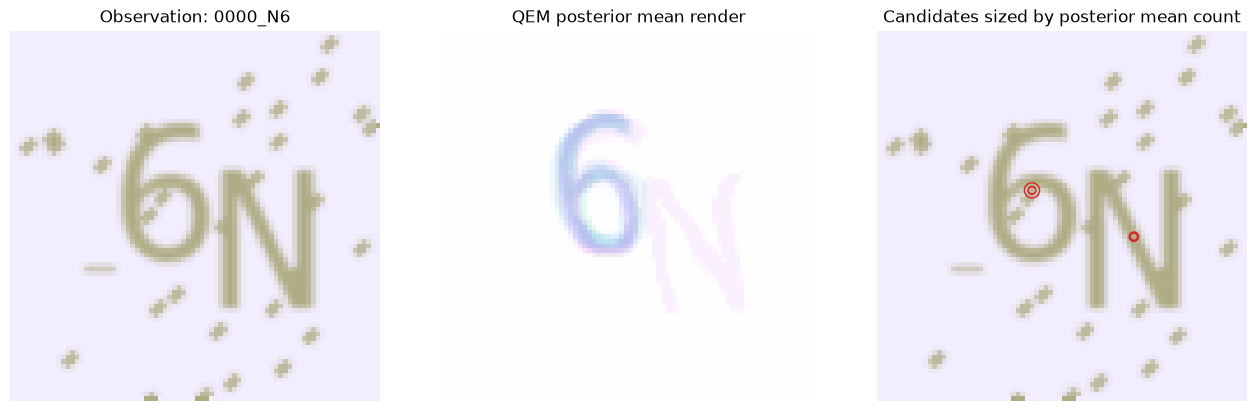

In [5]:
count_mean = np.asarray(
    result.qem_result.state.mean_params["candidate_counts"]["x"]
)[0]
posterior_mean = np.asarray(result.reconstructions).mean(axis=0)[0]

figure, axes = plt.subplots(1, 3, figsize=(13, 4),
                            constrained_layout=True)
axes[0].imshow(np.asarray(images[0]))
axes[0].set_title(f"Observation: {selected_path.stem}")
axes[0].set_axis_off()
axes[1].imshow(np.clip(posterior_mean, 0.0, 1.0))
axes[1].set_title("QEM posterior mean render")
axes[1].set_axis_off()
plot_candidate_sites(
    axes[2], images[0], result.candidate_sites, count_mean
)
axes[2].set_title("Candidates sized by posterior mean count")
print(f"QEM alternatives per factor: {NUM_SAMPLES}")
print(f"QEM updates: {NUM_STEPS}")
print(f"Candidate sites:\n{np.asarray(result.candidate_sites)}")
print(f"Posterior mean counts:\n{count_mean.round(3)}")


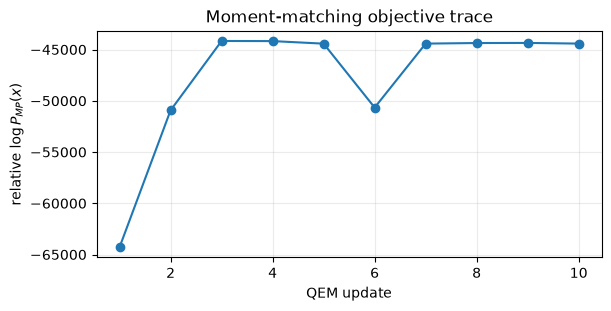

In [6]:
log_marginals = np.asarray(result.qem_result.log_marginals)
figure, axis = plt.subplots(figsize=(6, 3), constrained_layout=True)
axis.plot(np.arange(1, len(log_marginals) + 1), log_marginals, marker="o")
axis.set_xlabel("QEM update")
axis.set_ylabel(r"relative $\log P_{MP}(x)$")
axis.set_title("Moment-matching objective trace")
axis.grid(alpha=0.25)
assert np.isfinite(log_marginals).all()
assert np.isfinite(posterior_mean).all()


## Interpretation

The objective is relative because the latent-independent omitted-count
factor is hidden from MPIW's packing operation. This changes neither QEM's
normalized weights nor its moment updates. Candidate selection remains the
important approximation: a glyph absent from the shortlist cannot receive
posterior mass.
